## Import packages

In [1]:
# Libraries for data handling
import pandas as pd
import numpy as np

# Library for chemical data
import rdkit
from rdkit import Chem

# Libraries for statistics
from sklearn.model_selection import train_test_split
from imblearn.datasets import make_imbalance
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.utils.class_weight import compute_sample_weight

 # Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pprint

# Libraries for modelling
from itertools import combinations
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor


## Data processing

In [ ]:
# Read in the dataset containing the aminoxyl catalyst features
file_path = '.../oxo_data_final.csv'
oxo_data = pd.read_csv(file_path)

oxo_data.head()

,Compound_Name,condition_avg_ddG++,condition_1_ddG++,condition_2_ddG++,condition_3_ddG++,condition_1_ee,condition_2_ee,condition_3_ee,log_ddG++,log_ddG++_+1,...,Buried_Sterimol_B1_C1_C3_5.0(Å)_min,Buried_Sterimol_B1_C1_C3_5.0(Å)_max,Buried_Sterimol_B1_C1_C3_5.0(Å)_range,Buried_Sterimol_B1_C1_C3_5.0(Å)_low_E,Buried_Sterimol_B5_C1_C3_5.0(Å)_Boltz,Buried_Sterimol_B5_C1_C3_5.0(Å)_Boltz_stdev,Buried_Sterimol_B5_C1_C3_5.0(Å)_min,Buried_Sterimol_B5_C1_C3_5.0(Å)_max,Buried_Sterimol_B5_C1_C3_5.0(Å)_range,Buried_Sterimol_B5_C1_C3_5.0(Å)_low_E
0,oxoammo1,1.416241,1.30,1.538956,1.409768,81.0,87.0,84.0,0.114305,0.361728,...,2.062904,2.062904,0,2.062904,5.780765,0,5.780765,5.780765,0,5.780765
1,oxoammo10,0.003848,0.00,0.011545,0.000000,0.0,1.0,0.0,NaN,0.000000,...,1.875394,1.875394,0,1.875394,4.545838,0,4.545838,4.545838,0,4.545838
2,oxoammo11,0.018734,0.01,0.000000,0.046202,1.0,0.0,4.0,-1.937615,0.004321,...,2.023993,2.023993,0,2.023993,6.943412,0,6.943412,6.943412,0,6.943412
3,oxoammo12,0.136831,0.12,0.104181,0.186311,10.0,9.0,16.0,-0.936176,0.049218,...,2.021850,2.021850,0,2.021850,6.245721,0,6.245721,6.245721,0,6.245721
4,oxoammo14,0.808828,0.84,0.855918,0.730566,62.0,63.0,56.0,-0.077289,0.264818,...,3.094440,3.094440,0,3.094440,6.223164,0,6.223164,6.223164,0,6.223164


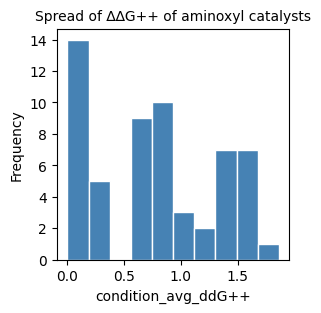

In [3]:
# Visualize the dataset
plt.figure(figsize=(3,3))
plt.title('Spread of ∆∆G++ of aminoxyl catalysts', fontsize=10)
plt.hist(oxo_data["condition_avg_ddG++"], color='#4682B4', edgecolor='white')
plt.xlabel("condition_avg_ddG++", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

In [4]:
# Preprocessing

# Define target column
target_column = "condition_avg_ddG++"

# Drop non-feature columns
drop_cols = [
    "condition_1_ddG++", "condition_2_ddG++", "condition_3_ddG++",
    "condition_1_ee", "condition_2_ee", "condition_3_ee",
    "log_ddG++", "log_ddG++_+1"
]
oxo_data = oxo_data.drop(columns=drop_cols, errors="ignore")

# Keep only numeric columns
oxo_data = oxo_data.select_dtypes(include=[np.number])

# Remove columns with irrelevant information
suffixes = ("_range", "_stdev", "_low_E")
oxo_data = oxo_data[[c for c in oxo_data.columns if not c.endswith(suffixes)]]

# Drop if any of the values have 0 variance
def remove_zero_std_cols(df, keep_col='condition_avg_ddG++'):
    zero_std_cols = df.columns[df.std() == 0]
    zero_std_cols = zero_std_cols.drop(keep_col, errors='ignore')  # Exclude target column
    df = df.drop(columns=zero_std_cols)
    print(f"Dropping {len(zero_std_cols)} features: {list(zero_std_cols)}")
    return df
oxo_data = remove_zero_std_cols(oxo_data)

print("Total remaining features", len(oxo_data.columns))

oxo_data.head()

Dropping 0 features: []
Total remaining features 190


,condition_avg_ddG++,HOMO_Boltz,HOMO_min,HOMO_max,LUMO_Boltz,LUMO_min,LUMO_max,μ_Boltz,μ_min,μ_max,...,Buried_Sterimol_B5_C1_C2_5.0(Å)_max,Buried_Sterimol_L_C1_C3_5.0(Å)_Boltz,Buried_Sterimol_L_C1_C3_5.0(Å)_min,Buried_Sterimol_L_C1_C3_5.0(Å)_max,Buried_Sterimol_B1_C1_C3_5.0(Å)_Boltz,Buried_Sterimol_B1_C1_C3_5.0(Å)_min,Buried_Sterimol_B1_C1_C3_5.0(Å)_max,Buried_Sterimol_B5_C1_C3_5.0(Å)_Boltz,Buried_Sterimol_B5_C1_C3_5.0(Å)_min,Buried_Sterimol_B5_C1_C3_5.0(Å)_max
0,1.416241,-0.27581,-0.27581,-0.27581,0.02716,0.02716,0.02716,-0.124325,-0.124325,-0.124325,...,4.493012,3.630083,3.630083,3.630083,2.062904,2.062904,2.062904,5.780765,5.780765,5.780765
1,0.003848,-0.29261,-0.29261,-0.29261,0.05696,0.05696,0.05696,-0.117825,-0.117825,-0.117825,...,5.367441,5.569201,5.569201,5.569201,1.875394,1.875394,1.875394,4.545838,4.545838,4.545838
2,0.018734,-0.26278,-0.26278,-0.26278,0.02719,0.02719,0.02719,-0.117795,-0.117795,-0.117795,...,4.488093,4.295511,4.295511,4.295511,2.023993,2.023993,2.023993,6.943412,6.943412,6.943412
3,0.136831,-0.28570,-0.28570,-0.28570,0.02804,0.02804,0.02804,-0.128830,-0.128830,-0.128830,...,4.486653,4.293818,4.293818,4.293818,2.021850,2.021850,2.021850,6.245721,6.245721,6.245721
4,0.808828,-0.29269,-0.29269,-0.29269,0.00390,0.00390,0.00390,-0.144395,-0.144395,-0.144395,...,4.022198,5.308480,5.308480,5.308480,3.094440,3.094440,3.094440,6.223164,6.223164,6.223164


In [5]:
# Preprocessing to remove highly correlated features
def remove_highly_correlated(df, keep_col='condition_avg_ddG++', exclude_cols=None):
    if exclude_cols is None:
        exclude_cols = []
    df_corr = df.corr().abs()
    upper = df_corr.where(np.triu(np.ones(df_corr.shape), k=1).astype(bool))
    to_drop = [
        column for column in upper.columns 
        if any(upper[column] > 0.8) and column != keep_col and column not in exclude_cols
    ]
    df = df.drop(columns=to_drop)
    print(f"Dropping {len(to_drop)} features")
    return df

# Define features to preserve
excluded_columns = ['P_int', 
                    'Quad_Magnitude', 
                    'dipole(Debye)_Boltz', 
                    'polar_iso(au)_Boltz',
                    '%Vbur_C1_3.0Å_Boltz',
                    '%Vbur_C1_5.0Å_Boltz',
                    'Buried_Sterimol_B5_C1_C3_3.0(Å)_Boltz',
                    'Buried_Sterimol_L_N1_C1_5.0(Å)_Boltz',
                    'Buried_Sterimol_B1_N1_C1_3.0(Å)_Boltz'
                    ]
oxo_data = remove_highly_correlated(oxo_data, exclude_cols=excluded_columns)

print("Total remaining features", len(oxo_data.columns) - 1)
pprint.pprint(list(oxo_data.columns)[1:])

Dropping 165 features
Total remaining features 24
['HOMO_Boltz',
 'LUMO_Boltz',
 'polar_iso(au)_Boltz',
 'dipole(Debye)_Boltz',
 'NBO_charge_N1_Boltz',
 'NBO_charge_C1_Boltz',
 'NBO_charge_C2_Boltz',
 'NMR_shift_N1_Boltz',
 'NMR_shift_C1_Boltz',
 '%Vbur_N1_3.0Å_Boltz',
 '%Vbur_C1_3.0Å_Boltz',
 '%Vbur_C1_5.0Å_Boltz',
 'Buried_Sterimol_L_N1_C1_3.0(Å)_Boltz',
 'Buried_Sterimol_B1_N1_C1_3.0(Å)_Boltz',
 'Buried_Sterimol_B5_C1_C3_3.0(Å)_Boltz',
 'pyramidalization_Gavrish_C1(°)_Boltz',
 'P_int',
 'Quad_XX',
 'Quad_XY',
 'Quad_XZ',
 'Quad_YZ',
 'Quad_Magnitude',
 'Buried_Sterimol_L_N1_C1_5.0(Å)_Boltz',
 'Buried_Sterimol_B5_N1_C1_5.0(Å)_Boltz']


## Dataset splitting

In [6]:
# Define Kennard-Stone algorithm for data splitting
def kennard_stone(X, n_samples):
    if isinstance(X, pd.DataFrame):
        X = X.values

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Compute distance matrix
    D = pairwise_distances(X_scaled, metric="euclidean")

    # Step 1: pick the two samples furthest apart
    i1, i2 = np.unravel_index(D.argmax(), D.shape)
    selected = [i1, i2]

    # Step 2: iteratively add the sample furthest from the already selected set
    while len(selected) < n_samples:
        remaining = list(set(range(len(X))) - set(selected))
        # distance to nearest selected sample
        dist_to_selected = [min(D[i, j] for j in selected) for i in remaining]
        # pick sample with max distance
        next_idx = remaining[np.argmax(dist_to_selected)]
        selected.append(next_idx)

    return np.array(selected)

# Apply selection process to dataset
test_split_ratio = 0.12 # manually chosen, between 0.1 and 0.2
n_external = round(oxo_data.shape[0]*test_split_ratio)

# Choose feature space
X = oxo_data[oxo_data.columns]  

# Run algorithm
external_indices = kennard_stone(X, n_external)

# Create external test set
external_test_set = oxo_data.iloc[external_indices].copy()

print("External test set:")
external_test_set

External test set:


,condition_avg_ddG++,HOMO_Boltz,LUMO_Boltz,polar_iso(au)_Boltz,dipole(Debye)_Boltz,NBO_charge_N1_Boltz,NBO_charge_C1_Boltz,NBO_charge_C2_Boltz,NMR_shift_N1_Boltz,NMR_shift_C1_Boltz,...,Buried_Sterimol_B5_C1_C3_3.0(Å)_Boltz,pyramidalization_Gavrish_C1(°)_Boltz,P_int,Quad_XX,Quad_XY,Quad_XZ,Quad_YZ,Quad_Magnitude,Buried_Sterimol_L_N1_C1_5.0(Å)_Boltz,Buried_Sterimol_B5_N1_C1_5.0(Å)_Boltz
53,0.007697,-0.27475,0.05797,71.6516,1.1989,-0.62997,-0.05973,-0.41033,202.3978,125.4462,...,4.349921,5.614958,14.957193,-2.2950,-1.9873,1.1375,0.9519,4.712463,4.594825,4.327050
32,1.414564,-0.29014,-0.03678,221.1200,6.4993,-0.84537,-0.04903,-0.04995,214.2672,127.8135,...,5.388971,5.441157,19.064503,-32.1988,-12.1475,-1.2272,0.3208,43.162887,6.195152,6.612208
51,0.017697,-0.29627,-0.01876,128.4400,6.9128,-0.83219,-0.05334,-0.25622,229.5098,152.2448,...,5.432364,2.871693,17.246959,-14.0586,-5.1279,-2.1500,-1.2622,19.413188,4.596266,6.855517
21,0.177553,-0.32203,0.01885,80.7244,2.1603,-0.81963,-0.10492,0.53647,219.7728,136.5654,...,5.094018,5.830026,15.269101,7.8727,-2.8118,-3.6436,-1.9211,12.107068,5.236373,6.629631
57,1.050000,-0.24034,-0.04128,277.9380,1.6778,-0.83328,-0.06321,-0.59521,210.1045,128.8675,...,3.271919,5.464515,20.168623,13.6980,-5.0161,3.4136,-0.0704,21.590075,5.850437,5.791358
49,0.917704,-0.28457,0.02539,171.9360,1.6384,-0.84179,-0.07433,-0.03681,209.9616,135.0453,...,5.414225,5.663136,18.180323,0.5976,1.6642,1.3290,0.8922,6.258239,6.503865,5.995775
44,0.003848,-0.30255,0.06199,80.8455,0.9846,-0.84787,-0.06443,-0.40182,227.4600,126.8764,...,4.289589,4.865270,14.985300,1.7192,-2.7280,-1.0275,-0.6701,5.492020,4.562370,5.514761


In [ ]:
# Save external test set
external_test_set.to_csv(".../oxo_data_final_test.csv", index=False)

# Define the training dataset
remaining_df = oxo_data.drop(external_test_set.index)

# Save the training dataset
remaining_df.to_csv(".../oxo_data_final_train.csv", index=False)

## Modelling

In [ ]:
# Read in training dataset
file_path = '.../oxo_data_final_train.csv'
oxo_data_train = pd.read_csv(file_path)

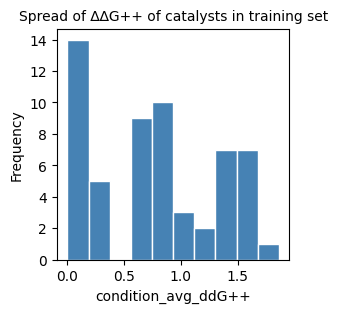

In [9]:
# Visualize training dataset
plt.figure(figsize=(3,3))
plt.title('Spread of ∆∆G++ of catalysts in training set', fontsize=10)
plt.hist(oxo_data["condition_avg_ddG++"], color='#4682B4', edgecolor='white')
plt.xlabel("condition_avg_ddG++", fontsize=10)
plt.ylabel("Frequency", fontsize=10)
plt.show()

In [10]:
# Features selected from shortlist after preprocessing based on empirical and NCI observations

all_features = ['polar_iso(au)_Boltz',
                'dipole(Debye)_Boltz',
                'NBO_charge_C1_Boltz',
                'NMR_shift_C1_Boltz',
                '%Vbur_C1_3.0Å_Boltz',
                '%Vbur_C1_5.0Å_Boltz',
                'Buried_Sterimol_L_N1_C1_3.0(Å)_Boltz',
                'Buried_Sterimol_B1_N1_C1_3.0(Å)_Boltz',
                'Buried_Sterimol_B5_C1_C3_3.0(Å)_Boltz',
                'pyramidalization_Gavrish_C1(°)_Boltz',
                'P_int',
                'Quad_Magnitude',
                'Buried_Sterimol_L_N1_C1_5.0(Å)_Boltz',
                'Buried_Sterimol_B5_N1_C1_5.0(Å)_Boltz'
                ]

In [11]:
# Model initialization

# Define target variable
target_col = 'condition_avg_ddG++'
y_full = oxo_data_train[target_col]

# Bin data to apply sample weights to emphasize underrepresented bins
n_bins = 5 # manually selected
y_binned = pd.qcut(y_full, q=n_bins, labels=False, duplicates='drop') + 1
sample_weights = compute_sample_weight(class_weight='balanced', y=y_binned)

# Show distribution of samples per bin (optional)
# unique_bins, counts = np.unique(y_binned, return_counts=True)
# print("Bin distribution:")
# for b, c in zip(unique_bins, counts):
#     print(f"  Bin {b}: {c} samples")

# Initialize scaler
scaler = StandardScaler()

# Initialize model
rf_model = RandomForestRegressor(n_estimators=10, max_depth=5, random_state=42, n_jobs=1)

# Returns R^2 and MAE for predictions
def calculate_metrics(y_true, y_pred):
    return r2_score(y_true, y_pred), mean_absolute_error(y_true, y_pred)

# Plots predictions
def plot_predictions(y_actual, y_pred, title):
    plt.figure(figsize=(5, 3))
    
    if 'Training' in title:
        color = '#4682B4'
        marker = 'o'
    else:
        color = '#32CD32'
        marker = '^'
    
    plt.scatter(
        y_actual, y_pred,
        c=color,
        marker=marker,
        alpha=0.7,
        edgecolors='black',
        linewidths=1.0,
        s=50
    )
    plt.plot(
        [y_actual.min(), y_actual.max()],
        [y_actual.min(), y_actual.max()],
        'k--', lw=2
    )
    plt.xlabel('Actual ∆∆G‡')
    plt.ylabel('Predicted ∆∆G‡')
    plt.title(f'{title} Data: Predicted vs. Actual ∆∆G‡')
    plt.tight_layout()
    plt.show()

# Stratified CV setup
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(X, y, y_binned, model, cv_strategy):
    metrics = {'train_r2': [], 'test_r2': [], 'train_mae': [], 'test_mae': []}
    train_preds_list, test_preds_list = [], []
    single_fold_test = {}

    for fold, (train_idx, test_idx) in enumerate(cv_strategy.split(X, y_binned)):
        # Split data into train and validation
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        y_train_binned, y_test_binned = y_binned[train_idx], y_binned[test_idx]

        # Scale inside the training fold
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        # Compute weights only from the training fold
        train_sample_weights = compute_sample_weight(
            class_weight="balanced",
            y=y_train_binned
        )

        # Fit model
        model.fit(X_train, y_train, sample_weight=train_sample_weights)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Metrics
        train_r2, train_mae = calculate_metrics(y_train, y_train_pred)
        test_r2, test_mae = calculate_metrics(y_test, y_test_pred)

        metrics['train_r2'].append(train_r2)
        metrics['test_r2'].append(test_r2)
        metrics['train_mae'].append(train_mae)
        metrics['test_mae'].append(test_mae)

        # Store predictions for analysis
        fold_train_preds = pd.DataFrame(
            {'y_true': y_train, 'y_pred': y_train_pred}, index=y_train.index
        )
        train_preds_list.append(fold_train_preds)

        fold_test_preds = pd.DataFrame(
            {'y_true': y_test, 'y_pred': y_test_pred}, index=y_test.index
        )
        test_preds_list.append(fold_test_preds)

        if fold == 0:  # Keep single fold test info for plotting
            single_fold_test['indices'] = y_test.index
            single_fold_test['y_true'] = y_test.values
            single_fold_test['y_pred'] = y_test_pred

    train_preds_df = pd.concat(train_preds_list)
    test_preds_df = pd.concat(test_preds_list)

    return metrics, train_preds_df, test_preds_df, single_fold_test

# For storing all combination results
results_summary = []


In [12]:
# Model creation

# Perform feature combination search
for k in range(2, 5):  # No more than 5 feature model given size of dataset
    for feature_combo in combinations(all_features, k):
        selected_features = list(feature_combo)
        X = oxo_data_train[selected_features]
        y = y_full.copy()

        metrics, _, _, _ = evaluate_model(
            X, y, y_binned.values, rf_model, cv_strategy
        )

        avg_metrics = {metric: np.mean(scores) for metric, scores in metrics.items()}
        avg_metrics['features'] = selected_features
        results_summary.append(avg_metrics)

# Compile results
results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values(by='test_r2', ascending=False)

# Deduplicate by feature set 
results_df['features_tuple'] = results_df['features'].apply(tuple) 
results_df = results_df.drop_duplicates(subset='features_tuple', keep='first') 
results_df = results_df.reset_index(drop=True)

# Show top 5 performing models by test R²
print("\nTop 5 Performing Models (by test R²):")
top_5_models = results_df.head(5)

for i, row in top_5_models.iterrows():
    features = row['features']
    r2_top_5 = row['test_r2']
    print(f"Model {i+1}: R² = {r2_top_5:.4f}, Features = {features}")


Top 5 Performing Models (by test R²):
Model 1: R² = 0.8045, Features = ['NBO_charge_C1_Boltz', '%Vbur_C1_3.0Å_Boltz', 'Buried_Sterimol_B5_C1_C3_3.0(Å)_Boltz']
Model 2: R² = 0.8034, Features = ['%Vbur_C1_3.0Å_Boltz', 'Buried_Sterimol_B5_C1_C3_3.0(Å)_Boltz']
Model 3: R² = 0.8014, Features = ['%Vbur_C1_3.0Å_Boltz', '%Vbur_C1_5.0Å_Boltz', 'Buried_Sterimol_B5_C1_C3_3.0(Å)_Boltz']
Model 4: R² = 0.8009, Features = ['polar_iso(au)_Boltz', '%Vbur_C1_3.0Å_Boltz', 'Buried_Sterimol_B5_C1_C3_3.0(Å)_Boltz']
Model 5: R² = 0.7995, Features = ['NBO_charge_C1_Boltz', '%Vbur_C1_3.0Å_Boltz', 'Buried_Sterimol_B5_C1_C3_3.0(Å)_Boltz', 'P_int']


In [13]:
# Determine best model automatically based on full-data MAE
best_mae = np.inf
best_model_idx = None

for idx in range(len(top_5_models)):
    features = top_5_models.iloc[idx]['features']
    X_curr = oxo_data_train[features]
    X_curr_scaled = StandardScaler().fit_transform(X_curr)

    # Compute sample weights
    sample_weights_full = compute_sample_weight(
        class_weight="balanced",
        y=y_binned.values
    )

    # Fit model
    rf_model.fit(X_curr_scaled, y_full, sample_weight=sample_weights_full)

    # Predict on full dataset
    y_pred = rf_model.predict(X_curr_scaled)
    full_mae = mean_absolute_error(y_full, y_pred)

    # Keep track of best (lowest MAE)
    if full_mae < best_mae:
        best_mae = full_mae
        best_model_idx = idx

# Use the best model
selected_model = best_model_idx
best_features = top_5_models.iloc[selected_model]['features']
print(f"\nAutomatically selected Model {selected_model + 1} with lowest MAE={best_mae:.4f}")
print(f"Selected feature combination: {best_features}")

# Prepare data using the selected feature combination
X_best = oxo_data_train[best_features]
y = y_full.copy()


Automatically selected Model 5 with lowest MAE=0.1035
Selected feature combination: ['NBO_charge_C1_Boltz', '%Vbur_C1_3.0Å_Boltz', 'Buried_Sterimol_B5_C1_C3_3.0(Å)_Boltz', 'P_int']



Performance on Best Feature Combo:
Average Train R2: 0.9467
Average Test R2: 0.7995
Average Train Mae: 0.1006
Average Test Mae: 0.1968


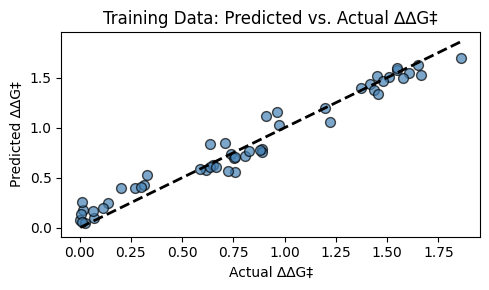

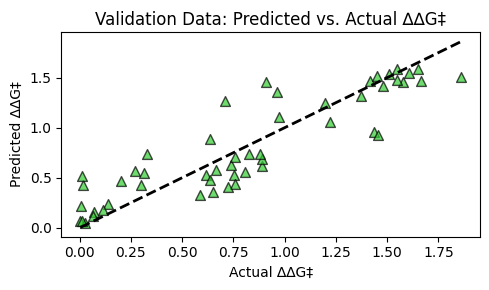

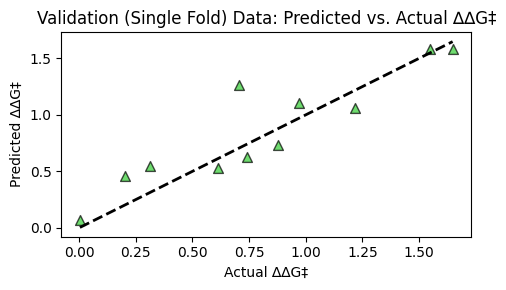

In [14]:
# Re-run evaluation on best feature combo to get predictions
metrics, train_preds_df, test_preds_df, single_fold_test = evaluate_model(
    X_best, y, y_binned.values, rf_model, cv_strategy
)

# After CV
# Average predictions
train_preds_mean = train_preds_df.groupby(train_preds_df.index).mean()
test_preds_mean = test_preds_df.groupby(test_preds_df.index).mean()

# Print metrics
print("\nPerformance on Best Feature Combo:")
average_metrics = {metric: np.mean(scores) for metric, scores in metrics.items()}
for metric, avg_score in average_metrics.items():
    print(f"Average {metric.replace('_', ' ').title()}: {round(avg_score, 4)}")

# Plot predictions
plot_predictions(train_preds_mean['y_true'], train_preds_mean['y_pred'], 'Training')
plot_predictions(test_preds_mean['y_true'], test_preds_mean['y_pred'], 'Validation')
plot_predictions(single_fold_test['y_true'], single_fold_test['y_pred'], 'Validation (Single Fold)')


In [15]:
# Model control tests

# Y-shuffle test
from sklearn.utils import shuffle
y_shuffled = shuffle(y, random_state=42)
metrics_shuffled, train_preds_df_shuffled, test_preds_df_shuffled, single_fold_test_shuffled = evaluate_model(X_best, y_shuffled, y_binned.values, rf_model, cv_strategy)

train_preds_mean_shuffled = train_preds_df_shuffled.groupby(train_preds_df_shuffled.index).mean()
test_preds_mean_shuffled = test_preds_df_shuffled.groupby(test_preds_df_shuffled.index).mean()

print("Y-Shuffled Performance on Best Feature Combo:")
average_metrics_shuffled = {metric: np.mean(scores) for metric, scores in metrics_shuffled.items()}
for metric, avg_score in average_metrics_shuffled.items():
    print(f"Average {metric.replace('_', ' ').title()}: {round(avg_score, 4)}")


# Y-mean test
metrics_ymean = {'train_r2': [], 'test_r2': [], 'train_mae': [], 'test_mae': []}

for fold, (train_idx, test_idx) in enumerate(cv_strategy.split(X, y_binned)):
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    ymean_value = y_train.mean()
    y_train_pred = np.full_like(y_train, ymean_value, dtype=float)
    y_test_pred = np.full_like(y_test, ymean_value, dtype=float)

    metrics_ymean['train_r2'].append(r2_score(y_train, y_train_pred))
    metrics_ymean['test_r2'].append(r2_score(y_test, y_test_pred))
    metrics_ymean['train_mae'].append(mean_absolute_error(y_train, y_train_pred))
    metrics_ymean['test_mae'].append(mean_absolute_error(y_test, y_test_pred))

average_metrics_ymean = {m: np.mean(v) for m, v in metrics_ymean.items()}
print("\nY-Mean Baseline Performance:")
for metric, avg_score in average_metrics_ymean.items():
    print(f"Average {metric.replace('_', ' ').title()}: {avg_score:.4f}")

Y-Shuffled Performance on Best Feature Combo:
Average Train R2: 0.7515
Average Test R2: -0.5964
Average Train Mae: 0.2252
Average Test Mae: 0.5544

Y-Mean Baseline Performance:
Average Train R2: 0.0000
Average Test R2: -0.0148
Average Train Mae: 0.4594
Average Test Mae: 0.4625


In [16]:
# Redefine final model

scaler = StandardScaler()
X_best_scaled = scaler.fit_transform(X_best)
sample_weights_full = compute_sample_weight(
class_weight="balanced",
y=y_binned.values
)

rf_model.fit(X_best_scaled, y, sample_weight=sample_weights_full)
print("Model training complete")

# Predict with final trained model
y_pred_final = rf_model.predict(X_best_scaled)

# Metrics
final_mae = mean_absolute_error(y, y_pred_final)
final_r2 = r2_score(y, y_pred_final)

print(f"Final Model (All Training Data) - MAE: {final_mae:.2f}, R²: {final_r2:.2f}")

Model training complete
Final Model (All Training Data) - MAE: 0.10, R²: 0.94


## SHAP feature analysis

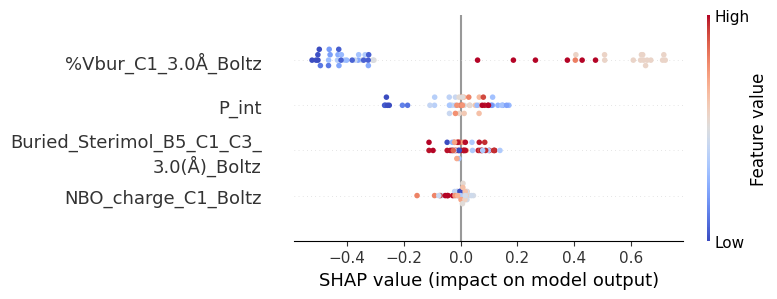

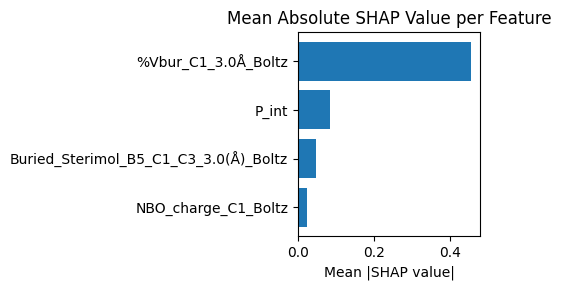

In [22]:
import shap
import warnings

# Replace long feature names with wrapped versions
wrapped_features = [
    name.replace("Buried_Sterimol_B5_C1_C3_3.0(Å)_Boltz", "Buried_Sterimol_B5_C1_C3_\n3.0(Å)_Boltz")
    for name in best_features
]

# Use the trained model
explainer = shap.TreeExplainer(rf_model)
warnings.filterwarnings("ignore", category=UserWarning, module="shap")
shap_values = explainer.shap_values(X_best_scaled)

# Plot
shap.summary_plot(shap_values, X_best_scaled, feature_names=wrapped_features, cmap=plt.get_cmap("coolwarm"))

# Compute mean absolute SHAP values for each feature
mean_abs_shap_values = np.abs(shap_values).mean(axis=0)

# Create a dataframe for better plotting
shap_df = pd.DataFrame({
    'Feature': best_features,
    'Mean |SHAP value|': mean_abs_shap_values
})

# Sort by importance
shap_df_sorted = shap_df.sort_values('Mean |SHAP value|', ascending=False)

# Plot
plt.figure(figsize=(5, 3))
plt.barh(shap_df_sorted['Feature'], shap_df_sorted['Mean |SHAP value|'])
plt.xlabel('Mean |SHAP value|')
plt.title('Mean Absolute SHAP Value per Feature')
plt.gca().invert_yaxis()  # Highest importance on top
plt.tight_layout()
plt.show()

## PCA plot

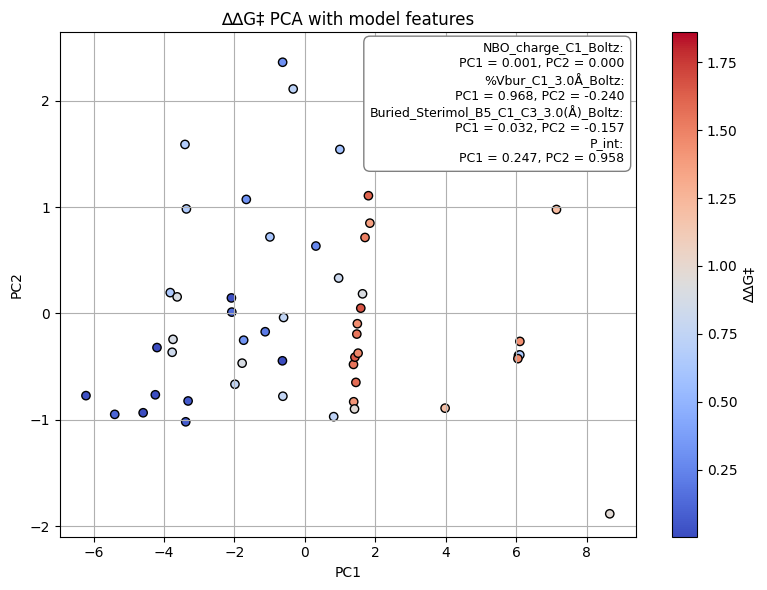

In [18]:
from sklearn.decomposition import PCA

# Define features
X_model = X_best.copy()
model_features = X_model.columns

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)

# Get PCA loadings
loadings = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2'],
                        index=model_features)

loadings_text = '\n'.join(
    [f"{feature}:\n PC1 = {loadings.loc[feature, 'PC1']:.3f}, PC2 = {loadings.loc[feature, 'PC2']:.3f}"
     for feature in model_features]
)

# Plot
plot_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    '∆∆G‡': y
}, index=X_model.index)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    plot_df['PC1'],
    plot_df['PC2'],
    c=plot_df['∆∆G‡'],
    cmap='coolwarm',
    edgecolor='k'
)
plt.colorbar(scatter, label='∆∆G‡')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('∆∆G‡ PCA with model features')
plt.grid(True)

plt.gca().text(
    0.98, 0.98, loadings_text,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray')
)

plt.tight_layout()
plt.show()

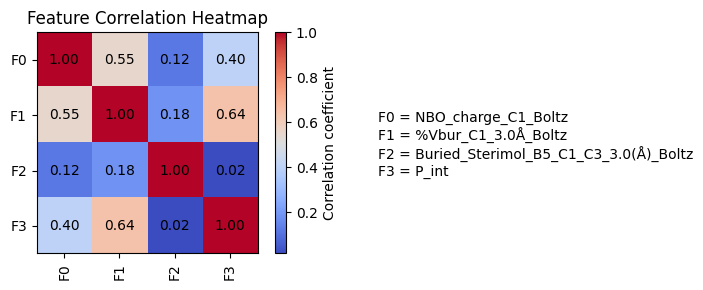

In [19]:
# Check if final features are correlated with each other

# Compute correlation matrix
corr_matrix = np.corrcoef(X_best, rowvar=False)

# Plot heatmap
plt.figure(figsize=(4, 3))
plt.imshow(corr_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar(label="Correlation coefficient")
plt.title("Feature Correlation Heatmap")

num_features = X_best.shape[1]
short_names = [f"F{i}" for i in range(num_features)]

plt.xticks(range(num_features), short_names, rotation=90)
plt.yticks(range(num_features), short_names)

for i in range(num_features):
    for j in range(num_features):
        plt.text(j, i, f"{corr_matrix[i, j]:.2f}",
                 ha="center", va="center", color="black")

plt.tight_layout()

feature_names = X_best.columns
mapping_text = "\n".join(f"{short} = {real}" for short, real in zip(short_names, feature_names))
plt.gcf().text(1.05, 0.5, mapping_text, va='center')

plt.show()


## Evaluate model on external test set

External Test MAE: 0.1638
External Test R²: 0.7925


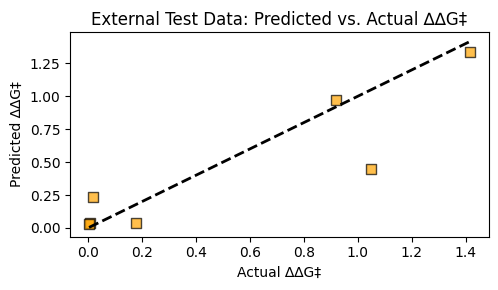

In [ ]:
# Read in external test set
file_path = ".../oxo_data_final_test.csv"

# Define target column
target_col = 'condition_avg_ddG++'

# Load external test data, scale features, and predict
def load_and_process_external_data(file_path, scaler, rf_model, features):
    df = pd.read_csv(file_path)

    # Apply previously fit scaler
    X_external = df[features]
    X_scaled = scaler.transform(X_external)

    # Predict with trained model
    predictions = rf_model.predict(X_scaled)
    return df, predictions

def plot_predictions(y_true, y_pred):
    plt.figure(figsize=(5, 3))
    plt.scatter(y_true, y_pred, color='#FFA500', marker='s', alpha=0.7, edgecolors='black', linewidths=1.0, s=50)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    plt.xlabel('Actual ∆∆G‡')
    plt.ylabel('Predicted ∆∆G‡')
    plt.title('External Test Data: Predicted vs. Actual ∆∆G‡')
    plt.tight_layout()
    plt.show()

# Run evaluation
external_df, y_pred_test = load_and_process_external_data(file_path, scaler, rf_model, X_best.columns)

if target_col in external_df.columns:
    y_true_test = external_df[target_col]
    r2, mae = calculate_metrics(y_true_test, y_pred_test)
    print(f"External Test MAE: {mae:.4f}")
    print(f"External Test R²: {r2:.4f}")
    plot_predictions(y_true_test, y_pred_test)

## Visualize results in final graph

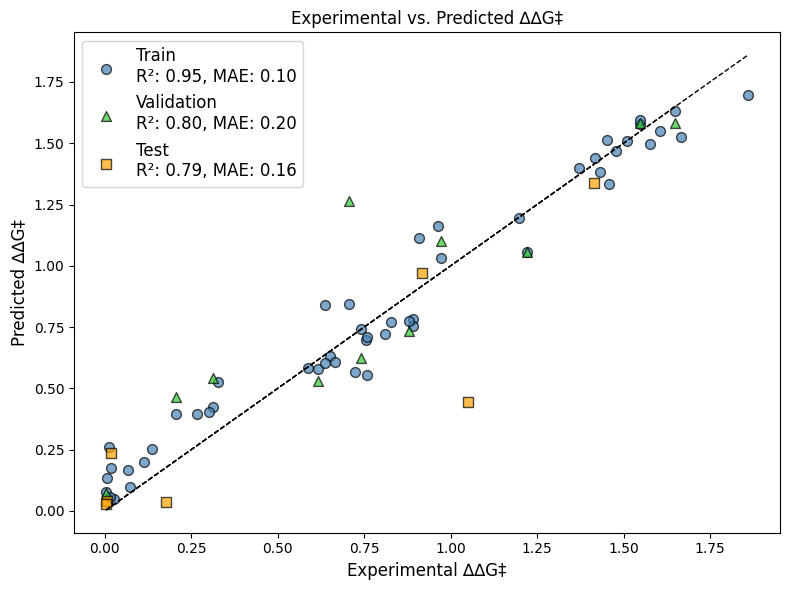

In [21]:
# Setup

def plot_predictions(y_true, y_pred, label, color, marker, ax):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    ax.scatter(y_true, y_pred, label=label, color=color, marker=marker, alpha=0.7, edgecolors='black', linewidths=1.0, s=50)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1)

    ax.set_xlabel('Experimental ∆∆G‡', fontsize = 12)
    ax.set_ylabel('Predicted ∆∆G‡', fontsize = 12)

def format_label(name, r2, mae):
    return f"{name}\nR²: {r2:.2f}, MAE: {mae:.2f}" if r2 is not None and mae is not None else f"{name}\n(No data)"

def plot_all_predictions(
    y_train, y_train_pred, train_mae, train_r2,
    y_val, y_val_pred, val_mae, val_r2,
    y_ext=None, y_ext_pred=None, ext_mae=None, ext_r2=None
):
    fig, ax = plt.subplots(figsize=(8, 6))

    datasets = [
        (y_train, y_train_pred, format_label('Train', train_r2, train_mae), '#4682B4', 'o'),
        (y_val, y_val_pred, format_label('Validation', val_r2, val_mae), '#32CD32', '^'),
        (y_ext, y_ext_pred, format_label('Test', ext_r2, ext_mae), '#FFA500', 's'),
    ]

    for y_true, y_pred, label, color, marker in datasets:
        if y_true is not None and y_pred is not None:
            plot_predictions(y_true, y_pred, label, color, marker, ax)

    ax.set_title('Experimental vs. Predicted ∆∆G‡', fontsize = 12)
    ax.legend(loc='upper left', fontsize = 12)
    plt.tight_layout()
    plt.show()

# Plot
plot_all_predictions(
    train_preds_mean['y_true'], train_preds_mean['y_pred'],
    average_metrics['train_mae'], average_metrics['train_r2'],

    single_fold_test['y_true'], single_fold_test['y_pred'],
    average_metrics['test_mae'], average_metrics['test_r2'],

    external_df[target_col], y_pred_test, mae, r2
)